# Preliminaries: Package imports and general definitions. 

In [1]:
using LinearAlgebra
using CairoMakie # For barplot. 
using SparseArrays
using BenchmarkTools 
using Plots

### First some definitions we need throughout the project.

In [2]:
h = 1/8; h2=h*h     # Stepsize over the domain we simulate
Np1 = convert(Int, 1/h+1)       # Number of nodes in one direction on domain, including boundary nodes.
                    # +1 to compensate for the boundaries. Take h=0.5, then 2 boundary and 1 interior point, but 1/h=2=>1/h+1
Np2 = Np1*Np1       # Number of nodes in the entire domain plus boundary

Nm1 = Np1-2         # Number of interior nodes in 1d.
Nm2 = Nm1*Nm1;      # Number of interior nodes in 2d. semicolon (;) to suppress jupyter output.

Nbnd = Np2-Nm2;     # Number of boundary noddes = total - internal

# Assignment 1: construct the vector $f^h$
We start by creating an (N+1) x (N+1) matrix, and reshape it so that all the columns make one long column vector of size (N+1)²x1

We fill the content of $f^h$ (while it is matrix) to be $x(x-1)y(y-1)$, with 0 on the boundaries. 

In [3]:
x = Vector(0:h:1);                                 # One-dimensional vector denoting boundary nodes.
Xh = collect(tuple(c,1-r) for r in x, c in x);     # Two dimensional-matrix containing tuples of all coordinates. 


fsource((x,y)) = x*(x-1)*y*(y-1);                  # Define desired function for f dep. x, y
F = fsource.(Xh);                                  # Feed the matrix using Xh, containing all the possible (x,y) pairs.

println("fh without zeros at boundary, and not resized")
println(F)
F[[begin, end], :] .= 0                            # Set F boundaries to zero
F[:, [begin, end]] .= 0;                           # This step is not technically necessary as x(x-1)y(y-1) is always zero when any of x=0, x=1, y=0 or y=1 are true, 
                                                   # which is also where the boundary lies.

fh without zeros at boundary, and not resized
[-0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 0.0; 0.0 0.011962890625 0.0205078125 0.025634765625 0.02734375 0.025634765625 0.0205078125 0.011962890625 -0.0; 0.0 0.0205078125 0.03515625 0.0439453125 0.046875 0.0439453125 0.03515625 0.0205078125 -0.0; 0.0 0.025634765625 0.0439453125 0.054931640625 0.05859375 0.054931640625 0.0439453125 0.025634765625 -0.0; 0.0 0.02734375 0.046875 0.05859375 0.0625 0.05859375 0.046875 0.02734375 -0.0; 0.0 0.025634765625 0.0439453125 0.054931640625 0.05859375 0.054931640625 0.0439453125 0.025634765625 -0.0; 0.0 0.0205078125 0.03515625 0.0439453125 0.046875 0.0439453125 0.03515625 0.0205078125 -0.0; 0.0 0.011962890625 0.0205078125 0.025634765625 0.02734375 0.025634765625 0.0205078125 0.011962890625 -0.0; 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 -0.0]


In [4]:
fh = reshape(F, length(x)^2, 1)                    # Reshape to (1/h², 1). length(x) is a convenient method to get integers.
println("fh with zeros, and after resizing")
println(fh)

fh with zeros, and after resizing
[0.0; 0.0; 0.0; 0.0; 0.0; 0.0; 0.0; 0.0; 0.0; 0.0; 0.011962890625; 0.0205078125; 0.025634765625; 0.02734375; 0.025634765625; 0.0205078125; 0.011962890625; 0.0; 0.0; 0.0205078125; 0.03515625; 0.0439453125; 0.046875; 0.0439453125; 0.03515625; 0.0205078125; 0.0; 0.0; 0.025634765625; 0.0439453125; 0.054931640625; 0.05859375; 0.054931640625; 0.0439453125; 0.025634765625; 0.0; 0.0; 0.02734375; 0.046875; 0.05859375; 0.0625; 0.05859375; 0.046875; 0.02734375; 0.0; 0.0; 0.025634765625; 0.0439453125; 0.054931640625; 0.05859375; 0.054931640625; 0.0439453125; 0.025634765625; 0.0; 0.0; 0.0205078125; 0.03515625; 0.0439453125; 0.046875; 0.0439453125; 0.03515625; 0.0205078125; 0.0; 0.0; 0.011962890625; 0.0205078125; 0.025634765625; 0.02734375; 0.025634765625; 0.0205078125; 0.011962890625; 0.0; 0.0; 0.0; 0.0; 0.0; 0.0; 0.0; 0.0; 0.0; 0.0;;]


We can see the vector $f^h$ is a column vector of size (9x1)=(1/h²x1), as desired. The boundaries are all set to zero, and the only value
we want to see lies at x=0.5, y=0.5 which has $0.5*(1-0.5)*0.5*(1-0.5)=0.5^4=0.0625$

# Assignment 2: Construct the matrix $A^h$
We create the matrix $A^h$ using a Kronecker product between the id. matrix and the one-dimensional $A^h$ (keeping in mind the homogeneous Dirichlet BC's).
We utilize the Kronecker product to make an $(N+1)^2$x$(N+1)^2$ matrix defining the difference operator $A^h$ in $A^hu=f^h$, so that $u=(A^{h})^{-1}f^h=A^h$ \ $ f^h$. 


In [5]:
ID = Diagonal(repeat([1],Np1))
curly_A = Tridiagonal(repeat([-1], Np1-1), repeat([2], Np1), repeat([-1], Np1-1)) #lower, middle, upper)

9×9 Tridiagonal{Int64, Vector{Int64}}:
  2  -1   ⋅   ⋅   ⋅   ⋅   ⋅   ⋅   ⋅
 -1   2  -1   ⋅   ⋅   ⋅   ⋅   ⋅   ⋅
  ⋅  -1   2  -1   ⋅   ⋅   ⋅   ⋅   ⋅
  ⋅   ⋅  -1   2  -1   ⋅   ⋅   ⋅   ⋅
  ⋅   ⋅   ⋅  -1   2  -1   ⋅   ⋅   ⋅
  ⋅   ⋅   ⋅   ⋅  -1   2  -1   ⋅   ⋅
  ⋅   ⋅   ⋅   ⋅   ⋅  -1   2  -1   ⋅
  ⋅   ⋅   ⋅   ⋅   ⋅   ⋅  -1   2  -1
  ⋅   ⋅   ⋅   ⋅   ⋅   ⋅   ⋅  -1   2

We construct the matrix $A^h$, ignoring BC's for a moment.

In [6]:
Ah_left = kron(curly_A, ID)
Ah_right = kron(ID, curly_A)
Ah = Ah_left + Ah_right

81×81 Matrix{Int64}:
  4  -1   0   0   0   0   0   0   0  …   0   0   0   0   0   0   0   0   0
 -1   4  -1   0   0   0   0   0   0      0   0   0   0   0   0   0   0   0
  0  -1   4  -1   0   0   0   0   0      0   0   0   0   0   0   0   0   0
  0   0  -1   4  -1   0   0   0   0      0   0   0   0   0   0   0   0   0
  0   0   0  -1   4  -1   0   0   0      0   0   0   0   0   0   0   0   0
  0   0   0   0  -1   4  -1   0   0  …   0   0   0   0   0   0   0   0   0
  0   0   0   0   0  -1   4  -1   0      0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0  -1   4  -1      0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0  -1   4      0   0   0   0   0   0   0   0   0
 -1   0   0   0   0   0   0   0   0      0   0   0   0   0   0   0   0   0
  0  -1   0   0   0   0   0   0   0  …   0   0   0   0   0   0   0   0   0
  0   0  -1   0   0   0   0   0   0      0   0   0   0   0   0   0   0   0
  0   0   0  -1   0   0   0   0   0      0   0   0   0   0   0   0   0   0
  ⋮ 

Then we re-introduce the homogeneous Dirichlet BC's:

In [7]:
#..construct the mesh indicator matrix IG 
#..this indicator matrix will allow to distinguish interior and boundary nodes 
#..in this indicator matrix the boundary nodes are easy to identify 
#..for interior nodes IG(i,j) = 0 and for the boundary nodes IG(i,j) = 1
#..next construct the indicator vector IGvec by reshaping the indicator matrix IG  
IG = ones(Np1,Np1); 
IG[2:end-1,2:end-1] = zeros(Nm1,Nm1); 
IGvec = reshape(IG,Np2,1); 
#..construct array with linear indices allowing to define interior and boundary nodes 
#..interior: index array with all indices of the interior nodes 
#..boundary: index array with indices of all the boundary nodes 
L = LinearIndices(IGvec); 
interior_cartesian = findall(x->x==0,IGvec);  interior = L[interior_cartesian]; 
boundary_cartesian = findall(x->x>0,IGvec); boundary = L[boundary_cartesian]; 

#..construct auxiliary vectors used in the 1D code as well 
e = ones(Np1);            #..same as in 1D.. 
e_bnd = ones(Nbnd); #..used to handle the boundary nodes 

#..Construct one-dimensional matrix
A1 = Tridiagonal(-e[2:end], 2*e, -e[2:end]); 
A1 = (1/h2)*A1;
I = Diagonal(e); 
I_bnd = Diagonal(e_bnd); 

#..Handle the Dirichlet boundary conditions in the matrix and the right-hand side vector 
Ah[boundary,boundary] = I_bnd; Ah[boundary,interior] = zeros(Nbnd, Nm2); 

# Assignment 3: Plot the matrix Ah for using the spy command

First we set h=1/3 in code blocks higher-up. Then we run the code until this point again and plot Ah.

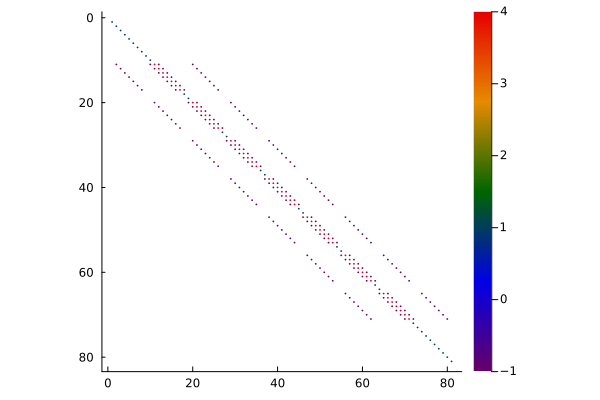

In [8]:
Plots.spy(Ah, markercolor = :darkrainbow)

# Assignment 4: Assume $u_{exact}$ is given. Compute and compare with finite differences.
We start by determining $f$ from $f=-\Delta\left(x(x-1)y(y-1)(x^2)(y^3)\right)$. This is a straightforward mathematical operation:

$f=-\Delta\left(x(x-1)y(y-1)(x^2)(y^3)\right)$

$=-(\frac{\partial^2}{\partial x^2}+\frac{\partial^2}{\partial y^2})\left(x^3(x-1)y^4(y-1)\right)$


$=-\frac{\partial^2}{\partial x^2}\left((x^4-x^3)(y^5-y^4)\right)-\frac{\partial^2}{\partial y^2}\left((x^4-x^3)(y^5-y^4)\right)$

$=-(12x^2-6x)(y^5-y^4)-(x^4-x^3)(20y^3-12y^2)$

To compare $u_{ex}$ to $u^{h}$, we simply find $u^h=A^h$ \ $f^h$. 

To this end, it is easier to wrap the generation of `Ah` and `fh` in a function, taking `h` as its argument. (And fh taking an expression as its argument)

In [9]:
function generate_fh(h, fsource)
    # Most of this code is copied from the above assignment 1. 

    # The input fsource is a function (x,y)->f(x,y). 
    x = Vector(0:h:1);
    Xh = collect(tuple(c,1-r) for r in x, c in x);
    
    F = fsource.(Xh);
    F[[begin, end], :] .= 0
    F[:, [begin, end]] .= 0
    fh = reshape(F, length(x)^2, 1)
    return fh
end

function generate_Ah(h)
    h2 = h*h
    Np1 = round(Int, 1/h) + 1
    Np2 = Np1*Np1
    Nm1 = Np1-2
    Nm2 = Nm1*Nm1
    Nbnd = Np2-Nm2

    ID = Diagonal(ones(Np1))
    curly_A = Tridiagonal(fill(-1,Np1-1), fill(2,Np1), fill(-1,Np1-1))

    Ah = (kron(curly_A, ID) + kron(ID, curly_A)) / h2

    IG = ones(Np1,Np1)
    IG[2:end-1,2:end-1] .= 0
    IGvec = reshape(IG,Np2,1)

    L = LinearIndices(IGvec)
    interior = L[findall(x->x==0, IGvec)]
    boundary = L[findall(x->x>0, IGvec)]

    I_bnd = Diagonal(ones(Nbnd))

    Ah[boundary,boundary] = I_bnd
    Ah[boundary,interior] .= 0

    return Ah
end

function find_u(h, A, f)
    Np1=convert(Int, 1/h+1)
    return reshape(A\f, Np1, Np1)
end

function get_grid(h)
    x = Vector(0:h:1);
    grid = collect(tuple(c,1-r) for r in x, c in x);
    return grid
end
;

In [10]:
# Generally true definitions for exercise 4
# The source function is the result of the above derivation.
u_exact((x,y)) = x^3*y^4*(x-1)*(y-1)
fsource((x,y)) = -(12*x^2-6*x)*(y^5-y^4)-(20*y^3-12*y^2)*(x^4-x^3)
;

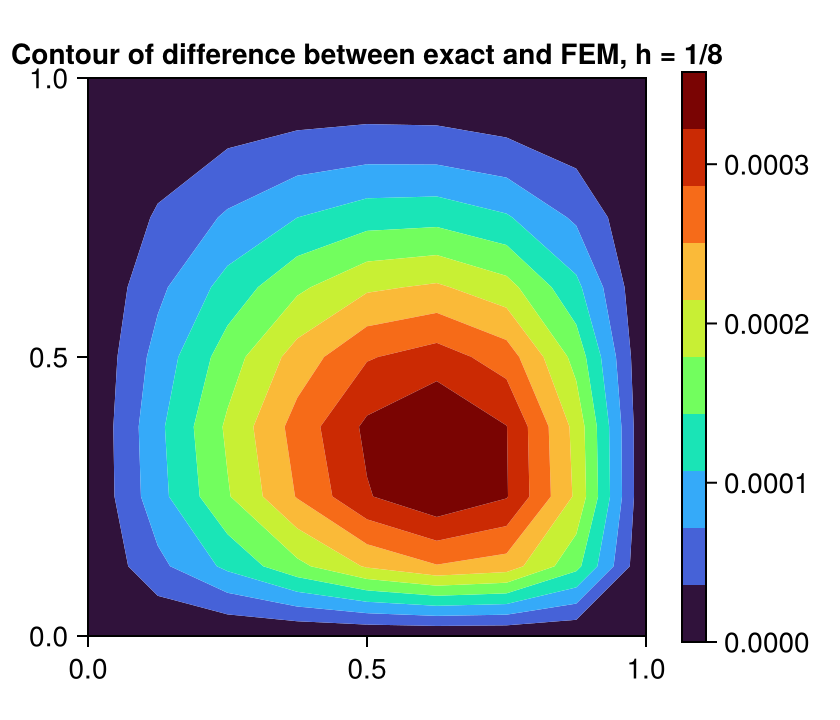

In [11]:
h = 1/8

fh = generate_fh(h, fsource)
Ah = generate_Ah(h)

x = 0:h:1
grid = get_grid(h)
true_solution = u_exact.(grid)

difference = find_u(h, Ah, fh) - true_solution

fig = Figure(size = (420, 360))
ax = Axis(fig[1, 1],
    title = "Contour of difference between exact and FEM, h = 1/8",
    aspect = DataAspect()
)

# Need to use the ' as Plots and CairoMakie have different column/row first ordering.
cf = CairoMakie.contourf!(ax, x, x, abs.(difference)', colormap = :turbo)

Colorbar(fig[1,2], cf)
fig

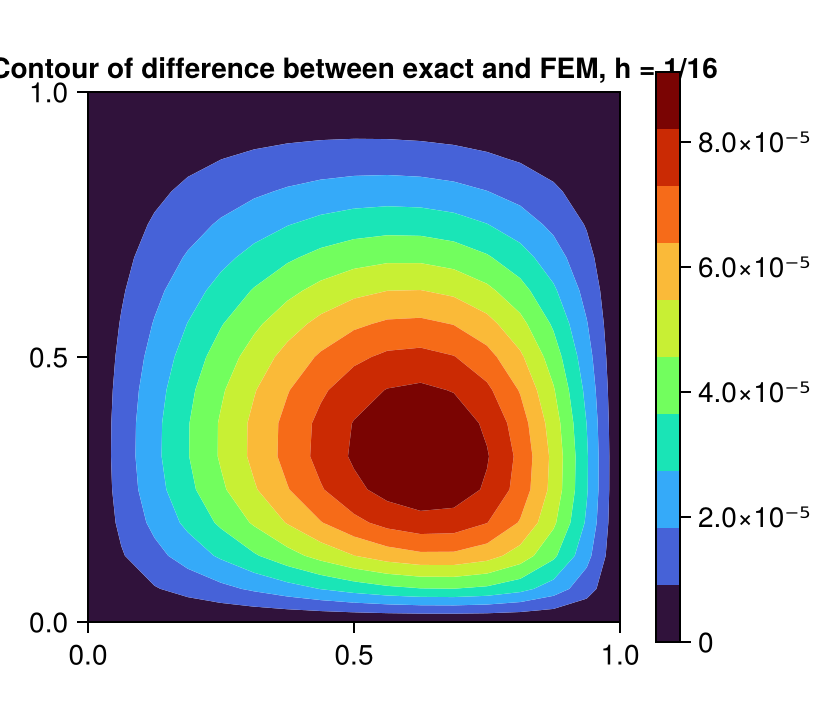

In [12]:
h = 1/16

fh = generate_fh(h, fsource)
Ah = generate_Ah(h)

x = 0:h:1
grid = get_grid(h)
true_solution = u_exact.(grid)

difference = find_u(h, Ah, fh) - true_solution

fig = Figure(size = (420, 360))
ax = Axis(fig[1, 1],
    title = "Contour of difference between exact and FEM, h = 1/16",
    aspect = DataAspect()
)

cf = CairoMakie.contourf!(ax, x, x, abs.(difference)', colormap = :turbo)

Colorbar(fig[1,2], cf)
fig

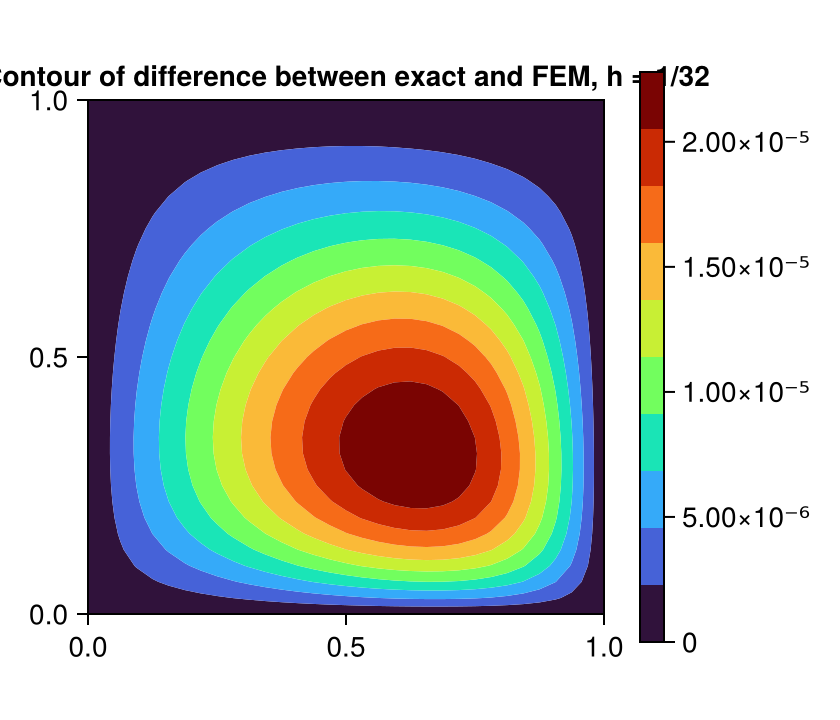

In [13]:
h = 1/32

fh = generate_fh(h, fsource)
Ah = generate_Ah(h)

x = 0:h:1
grid = get_grid(h)
true_solution = u_exact.(grid)

difference = find_u(h, Ah, fh) - true_solution

fig = Figure(size = (420, 360))
ax = Axis(fig[1, 1],
    title = "Contour of difference between exact and FEM, h = 1/32",
    aspect = DataAspect()
)

cf = CairoMakie.contourf!(ax, x, x, abs.(difference)', colormap = :turbo)

Colorbar(fig[1,2], cf)
fig

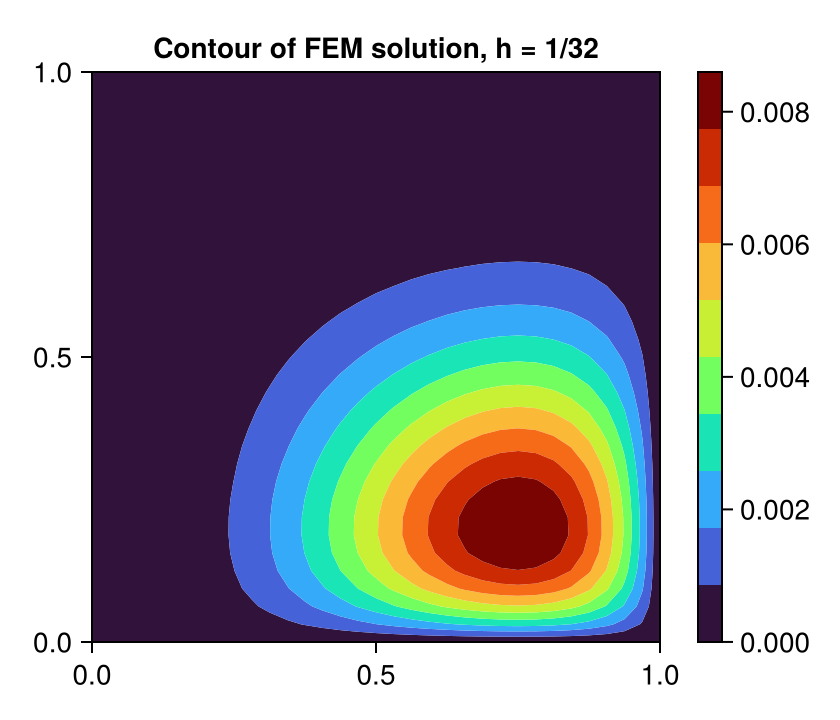

In [14]:
h=1/32
fig = Figure(size = (420, 360))
ax = Axis(fig[1, 1],
    title = "Contour of FEM solution, h = 1/32",
    aspect = DataAspect()
)

cf = CairoMakie.contourf!(ax, x, x, find_u(h, Ah, fh)', colormap = :turbo)

Colorbar(fig[1,2], cf)
fig

### Discuss the plots obtained

We can see in the contours that the shape of the error between the true solution and the simulated solution is similar for different values of h. The 'roughness' reduces for finer values of h, which makes sense.

As the error is too small to read from the legend (and the option colorbar_formatting=:scientific isn't working >:( ), we have to extract it using code. We see the following differences:

$h=1/8:$  error_min=$-3.578\cdot10^{-4}$, error_max=$1.2777\cdot 10^{-16}$

$h=1/16:$ error_min=$-9.120\cdot10^{-5}$, error_max=$3.580\cdot10{^-15}$

$h=1/32:$ error_min=$-2.279\cdot10^{-5}$, error_max=$1.089\cdot10^{-14}$

Clearly the maximal error is not of importance, as the largest error in absolute value appears in the minus sign. Here we can see that the error reduces 4x when the stepsize becomes 2x as small, so heuristically the error scales as O(h²). We know this to be true of a second-order difference problem when solving with our technique.

# Assignment 5: Compare CPU time for different approaches: $A^{-1}f$ or $A$\ $f$
First approach: using a backslash. 
Second approach: Using literal matrix inverse and matrix multiplication.
For both we time it using @btime


In [15]:
function method1(h)
    fh=generate_fh(h,fsource)
    Ah=generate_Ah(h)
    
    return Ah\fh
end

function method2(h)
    fh=generate_fh(h,fsource)
    Ah=generate_Ah(h)
    
    Ah_inv=inv(Ah)
    return Ah_inv * fh
end

h=1/64
# Commented out as these take long to run
# @btime method1(h)
# @btime method2(h)
;

Results of timing:
|h|Backslash|Literal inverse|
|---|---|---|
|1/8|0.120 ms|0.439ms|
|1/16|6.4 ms|12.2 ms|
|1/32|34.7 ms|84.8 ms|
|1/64|747.3 ms|2.251 s|

We can see that the literal inverse is around 2-3x slower than using the \ operator. 

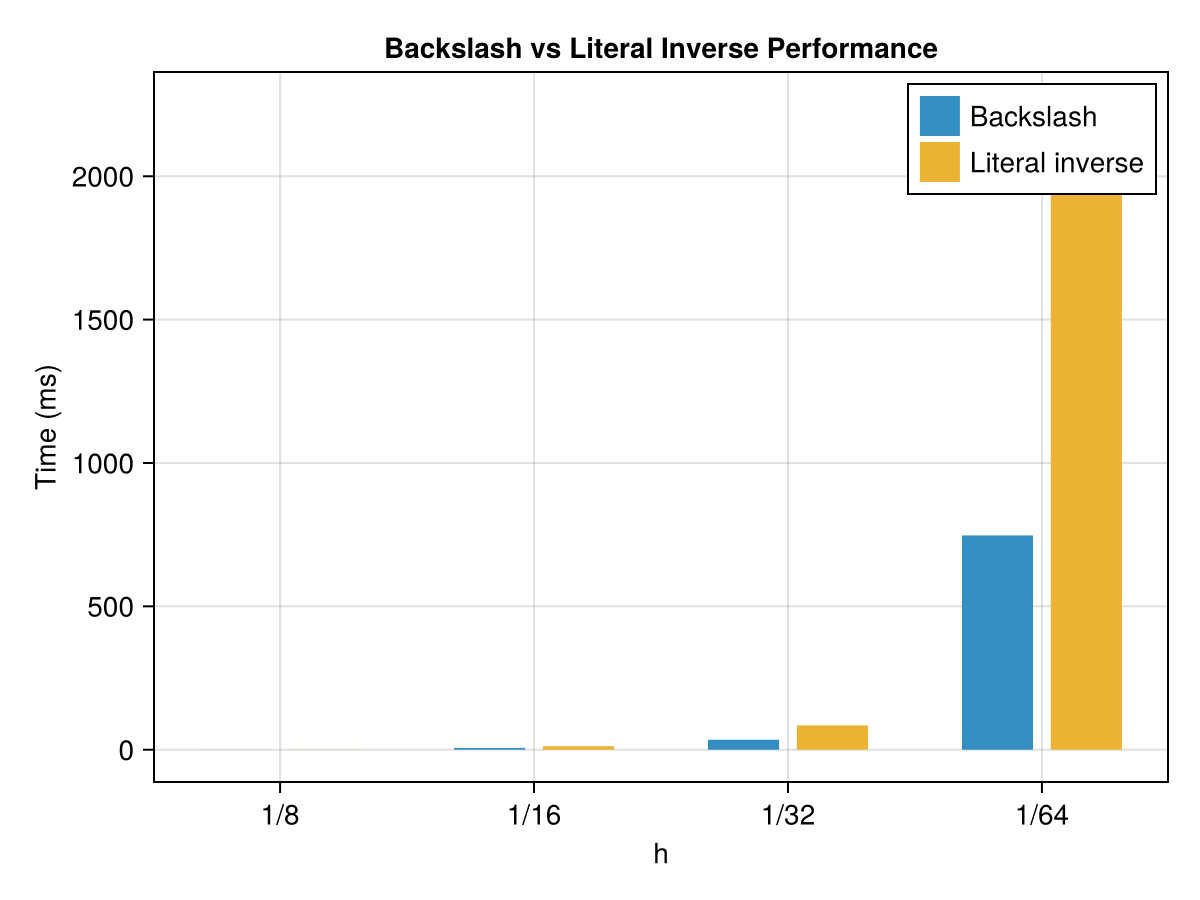

In [16]:
using CairoMakie

h_labels = ["1/8", "1/16", "1/32", "1/64"]
x = 1:length(h_labels)

backslash = [0.120, 6.4, 34.7, 747.3]
literal_inverse = [0.439, 12.2, 84.8, 2251.0]

# Bar width and offsets
w = 0.35

fig = Figure()
ax = Axis(fig[1, 1],
    xticks = (x, h_labels),
    xlabel = "h",
    ylabel = "Time (ms)",
    title = "Backslash vs Literal Inverse Performance"
)

barplot!(ax, x .- w/2, backslash, width = w, label = "Backslash")
barplot!(ax, x .+ w/2, literal_inverse, width = w, label = "Literal inverse")
axislegend(ax)

fig

# Assignment 6

We enforce A to be sparse. We do this by wrapping A

In [17]:
function generate_Ah_sparse(h)
    return generate_Ah(h)
end

generate_Ah_sparse(1/2)

9×9 Matrix{Float64}:
 1.0   0.0  0.0   0.0   0.0   0.0  0.0   0.0  0.0
 0.0   1.0  0.0   0.0   0.0   0.0  0.0   0.0  0.0
 0.0   0.0  1.0   0.0   0.0   0.0  0.0   0.0  0.0
 0.0   0.0  0.0   1.0   0.0   0.0  0.0   0.0  0.0
 0.0  -4.0  0.0  -4.0  16.0  -4.0  0.0  -4.0  0.0
 0.0   0.0  0.0   0.0   0.0   1.0  0.0   0.0  0.0
 0.0   0.0  0.0   0.0   0.0   0.0  1.0   0.0  0.0
 0.0   0.0  0.0   0.0   0.0   0.0  0.0   1.0  0.0
 0.0   0.0  0.0   0.0   0.0   0.0  0.0   0.0  1.0

# Assignment 7

We extend the functions generate_Ah and generate_fh to take arguments $Nx$ and $Ny$, the number of intervals in $x$- and $y$-direction.

In [18]:
function generate_Ah(Nx, Ny)
    # Nx, Ny: #intervals in x, y direction.
    
    hx = 1/Nx #Stepsize in x-direction
    hy = 1/Ny

    Npx = Nx + 1 # num. sim nodes in x-direc.
    Npy = Ny + 1
    Nmx = Nx - 1 # num. int. nodes in x-direc.
    Nmy = Ny - 1
    Nbnd = Npx*Npy - Nmx*Nmy

    IDx = Diagonal(ones(Npx))
    IDy = Diagonal(ones(Npy))
    
    curly_Ax = 1/hx^2 * Tridiagonal(fill(-1,Npx-1), fill(2,Npx), fill(-1,Npx-1))
    curly_Ay = 1/hy^2 * Tridiagonal(fill(-1,Npy-1), fill(2,Npy), fill(-1,Npy-1))

    Ah = kron(curly_Ax, IDy)+kron(IDx, curly_Ay)

    IG = ones(Npx, Npy)
    IG[2:end-1,2:end-1] .= 0
    IGvec = vec(IG') # Need to do it this way, as we need column-major flattening. Reshape doesn't do that.

    L = LinearIndices(IGvec)
    interior = L[findall(x->x==0, IGvec)]
    boundary = L[findall(x->x>0, IGvec)]

    I_bnd = Diagonal(ones(Nbnd))
    Ah[boundary, boundary] = I_bnd
    Ah[boundary, interior] .= 0

    return Ah
    
    # Ah = (kron(curly_A, ID) + kron(ID, curly_A)) / h2

    # IG = ones(Np1,Np1)
    # IG[2:end-1,2:end-1] .= 0
    # IGvec = reshape(IG,Np2,1)

    # L = LinearIndices(IGvec)
    # interior = L[findall(x->x==0, IGvec)]
    # boundary = L[findall(x->x>0, IGvec)]

    # I_bnd = Diagonal(ones(Nbnd))

    # Ah[boundary,boundary] = I_bnd
    # Ah[boundary,interior] .= 0

    # return Ah
end

function generate_fh(Nx, Ny, fsource)
    # Most of this code is copied from the above assignment 4. 

    # The input fsource is a function (x,y)->f(x,y). 
    grid = get_grid(Nx, Ny)
    
    F = fsource.(grid);
    F[[begin, end], :] .= 0
    F[:, [begin, end]] .= 0
    fh = reshape(F, length(grid), 1)
    return fh
end

function get_grid(Nx, Ny)
    x = Vector(0:1/Nx:1)
    y = Vector(0:1/Ny:1)
    grid = collect(tuple(c,1-r) for r in y, c in x);
    return grid
end
;

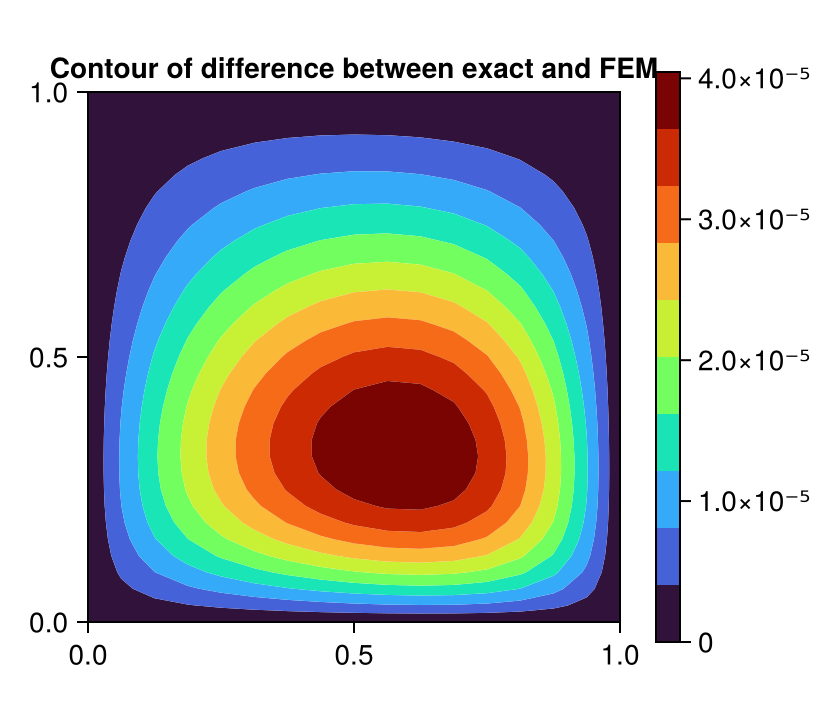

In [19]:
Nx=16
Ny=32

Ah=generate_Ah(Nx, Ny)
fh=generate_fh(Nx, Ny, fsource)
grid = get_grid(Nx, Ny)
u=reshape(Ah\fh, Ny+1, Nx+1)

# contour(Vector(0:1/Nx:1), Vector(0:1/Ny:1), u, fill="true", title="Contour of FEM", aspect_ratio=1, size=(1200,360), color=:turbo, lw=0);
x = collect(0:1/Nx:1)
y = collect(0:1/Ny:1)

Z = abs.(u .- u_exact.(grid))

fig = Figure(size = (420, 360))
ax = Axis(fig[1,1],
    title = "Contour of difference between exact and FEM",
    aspect = DataAspect()
)

cf = CairoMakie.contourf!(ax, x, y, Z', colormap = :turbo)

Colorbar(fig[1,2], cf)

fig

# Assignment 8: Extend implementation to case of E-field between two capacitor plates.

This exercise is asking to adapt the source function f such that it models a plate capacitor with charge +σ on one side, and -σ on the other. 
To achieve this I intend to change f_source to a more sophisticated function. 

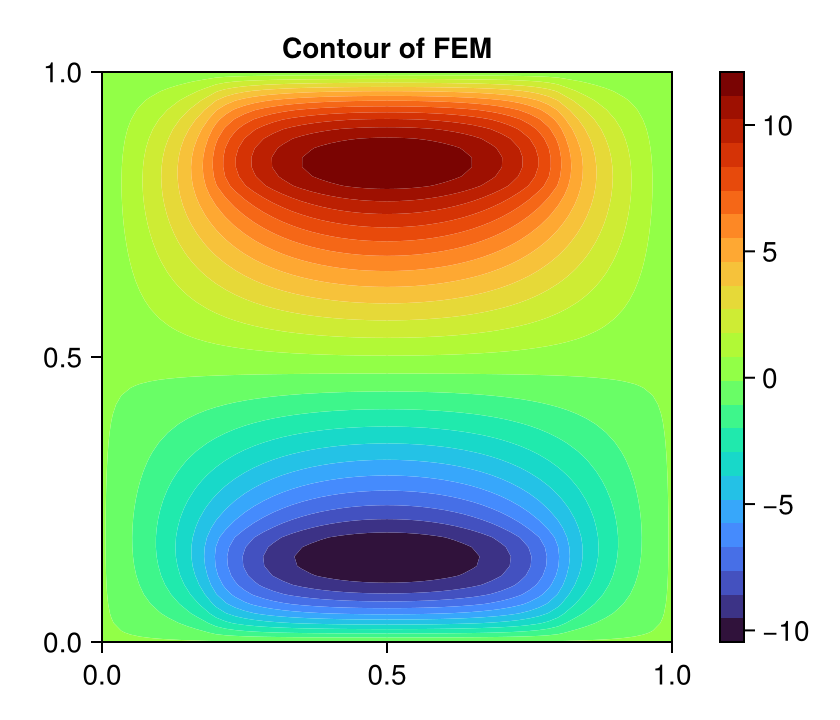

In [20]:
sigma = 1000

plate_width = 0.6
plate_thickness = 0.2
d = 0.6

function fsource((x,y))
    # Don't work too close to the boundaries
    if x < 0.5-plate_width/2 || x > 0.5+plate_width/2
        return 0
    # Inbetween y=0.8,,0.9
    elseif y > 0.5+d/2 && y < 0.5+d/2+plate_thickness
        return -sigma
    # Inbetween y=0.1,,0.2
    elseif y > 0.5-d/2-plate_thickness && y < 0.5-d/2
        return sigma
    end
    return 0
end   

Nx = 60
Ny = 60
Ah = generate_Ah(Nx,Ny)
fh = generate_fh(Nx,Ny,fsource)
u=reshape(Ah\fh, Ny+1, Nx+1)

x = collect(0:1/Nx:1)
y = collect(0:1/Ny:1)

fig = Figure(size = (420, 360))

ax = Axis(fig[1,1],
    title = "Contour of FEM",
    aspect = DataAspect()
)

cf = CairoMakie.contourf!(ax, x, y, u',   # transpose for Makie
    levels = 24,
    colormap = :turbo
)

Colorbar(fig[1,2], cf)

fig

# Assignment 9: Dielectrics (uh-oh)
We are now tasked to add _dielectrics_ into the mix. In the Poisson equation, these are represented as the epsilon_r we have so far ignored/assumed to be one: 

(Old model): $-\nabla^2u=p$

(New model): $-\nabla (\epsilon_r(x,y) \nabla u)=p$

We start by implementing a dielectric map, to describe where the dielectric is. We custom-taylor this dielectric map to be only the area between the plates, reusing some of the parameters we set in Exercise 9.

In [21]:
function epsilon_map((x, y))
    e_r = 6   # rel. permittivity

    # dielectric slab between plates
    if x > 0.5-plate_width/2 && x < 0.5+plate_width/2 && y < 0.5+d/2 && y > 0.5-d/2
        return e_r
    else
        return 1
    end
end;

# Get the epsilon at each simulation point on our grid.
function generate_eps(Nx, Ny, e_map)
    grid = get_grid(Nx, Ny)
    E = e_map.(grid)
    return reshape(E, Ny+1, Nx+1)
end

function generate_Ah(Nx, Ny, eps)
    hx = 1/Nx
    hy = 1/Ny

    Npx = Nx+1
    Npy = Ny+1
    N = Npx*Npy

    A = spzeros(N,N)

    idx(i,j) = (j-1)*Npy + i

    for j in 1:Npx
        for i in 1:Npy

            k = idx(i,j)

            # boundary nodes
            if i==1 || i==Npy || j==1 || j==Npx
                A[k,k] = 1
                continue
            end

            ec = eps[i,j]

            exp = (ec + eps[i,j+1])/2
            exm = (ec + eps[i,j-1])/2
            eyp = (ec + eps[i+1,j])/2
            eym = (ec + eps[i-1,j])/2

            A[k,k] =
                (exp+exm)/hx^2 +
                (eyp+eym)/hy^2

            A[k, idx(i,j+1)] = -exp/hx^2
            A[k, idx(i,j-1)] = -exm/hx^2
            A[k, idx(i+1,j)] = -eyp/hy^2
            A[k, idx(i-1,j)] = -eym/hy^2
        end
    end

    return A
end;

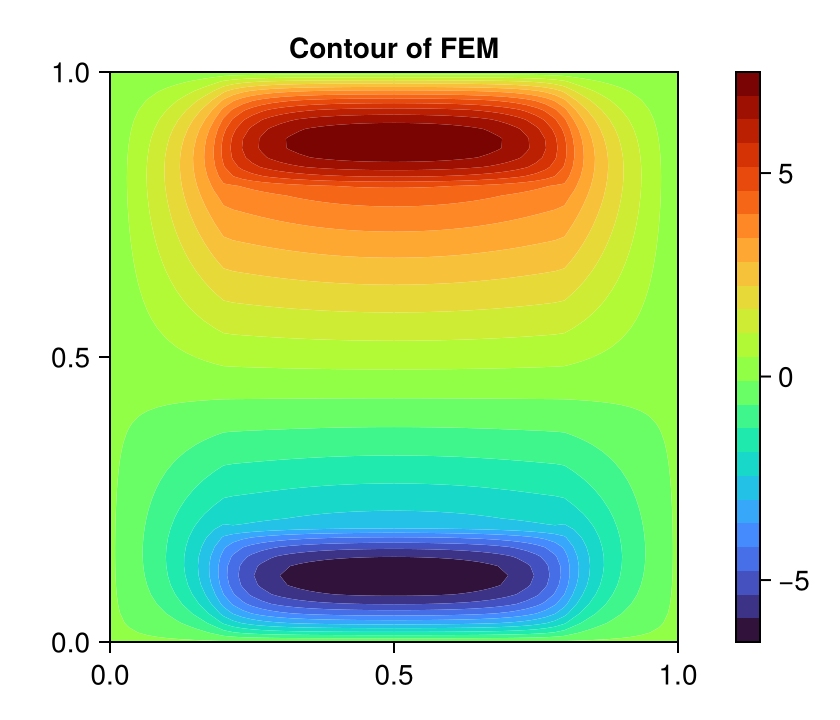

In [22]:
Nx = 60
Ny = 60

eps = generate_eps(Nx, Ny, epsilon_map)

Ah = generate_Ah(Nx,Ny,eps)
fh = generate_fh(Nx,Ny,fsource)

u = reshape(Ah \ fh, Ny+1, Nx+1)

x = collect(0:1/Nx:1)
y = collect(0:1/Ny:1)

fig = Figure(size = (420, 360))

ax = Axis(fig[1,1],
    title = "Contour of FEM",
    aspect = DataAspect()
)

cf = CairoMakie.contourf!(ax, x, y, u',   # transpose for Makie
    levels = 24,
    colormap = :turbo
)

Colorbar(fig[1,2], cf)

fig

We can see how the area with relative permittivity influences the construction of the field lines. Very clearly on the edge of the epsilon material we can see the field lines forming an angle between the materials. When we set e_r=1, we reacquire the original simulation!

# Assignment 10:
I've decided to... not get points for assignment 10 :)

# Request for course feedback
The slides are quite useful; especially the navigational system at the top is very nice-to-have. That being said, it overflows the width of the PDF, so some of the links are invisible/unreadable. I think the most important problem with the slides is that they are clearly presentation slides that _should_ be accompanied by a presentor and a story, but are (for our cohort, at least) not. To me it often feels like some information that should have be told between the bulletpoints is missing. It would be nice if these slides would be more aimed towards private study (for example: by making the "bulletpoint style" english into a proper, full story). In my opinion the best way to do this is to turn the slides into a small booklet or a reader. The chapter structure is there by merit of the slides, the story just needs to be written out.

I would also like to suggest Julia be taught form a slighty more elementary starting point. Most students know how to program, but the switch to Julia is in my opinion quite sudden. There are some fundamental differences to Julias and Pythons functioning, and it would be nice to hear from someone familiar with both (or just Julia) what the philosophies behind each language are, and how to get from Pythonic syntax to Julian syntax.

You can find my project on [Github]()